# XGBoost
XGBoost (Extreme Gradient Boosting) is an optimized distributed gradient boosting library designed to be highly efficient, flexible, and portable. It implements machine learning algorithms under the Gradient Boosting framework. XGBoost provides a parallel tree boosting (also known as GBDT, GBM) that solve many data science problems in a fast and accurate way. It is widely used for regression, classification, and ranking tasks.

```code
XGBoost = Gradient Boosting + Regularization + 2nd order optimization + Fast engineering
```

## Regularization
XGBoost includes a regularization term in its objective function to control model complexity and prevent overfitting. The regularization term penalizes complex models, encouraging simpler models that generalize better to unseen data. It's like if a student is trying to learn a subject, regularization is like a teacher who encourages the student to focus on the main concepts rather than memorizing every detail. But if the student tries to memorize everything, the teacher will penalize them for it, as a result student will be cautious about what to memorize and what to focus on.

The regularization term in XGBoost is defined as follows:

```math
\Omega(f) = \gamma T + \frac{1}{2} \lambda \sum_{j=1}^{T} w_j^2
```

Where:
- $\Omega(f)$ is the regularization term for the tree $f$.
- $\gamma$ is the complexity parameter that penalizes the number of leaves in the tree, in simple terms - leaf penalty.
- $T$ is the number of leaves in the tree.
- $\lambda$ is the L2 regularization term on leaf weights.
- $w_j$ is the weight of leaf $j$.

So, if a model has too many leaves or very large leaf weights, the regularization term will increase, leading to a higher overall objective function value aka penalty. This encourages the model to find a balance between fitting the training data well and keeping the model simple to avoid overfitting.

## 2nd Order Optimization
XGBoost uses second-order optimization techniques to improve the efficiency and accuracy of the model training process. Specifically, it utilizes both the first and second derivatives of the loss function to make more informed decisions during the optimization process. This allows XGBoost to converge faster and find better solutions compared to traditional gradient boosting methods that only use first-order derivatives.

The derivative of loss function is defined as follows:

```math
g_i = \frac{\partial l(y_i, \hat{y}_i)}{\partial \hat{y}_i} = 2(\hat{y}_i - y_i) \quad  \text{(first derivative)}
```

```math
h_i = \frac{\partial^2 l(y_i, \hat{y}_i)}{\partial \hat{y}_i^2} = 2 \quad \text{(second derivative)}
```

Where:
- $g_i$ is the first derivative (gradient) of the loss function with respect to the predicted value $\hat{y}_i$ for instance $i$.
- $h_i$ is the second derivative (Hessian) of the loss function with respect to the predicted value $\hat{y}_i$ for instance $i$.
- $l(y_i, \hat{y}_i)$ is the loss function that measures the difference between the true label $y_i$ and the predicted label $\hat{y}_i$ for each instance $i$.


In gradient boosting, the model is updated iteratively by using the gradients to determine the direction of improvement. By incorporating the second derivatives, XGBoost can also take into account the curvature of the loss function, allowing for more precise adjustments to the model parameters. This results in faster convergence and often leads to better overall performance of the model.

#### The objective function in XGBoost
The overall objective function in XGBoost combines the loss function and the regularization term to be minimized during the training process. It is defined as follows:

```math
Obj = \sum_{i=1}^{n} l(y_i, \hat{y}_i) + \sum_{k=1}^{K} \Omega(f_k)
```
Where:
- $Obj$ is the overall objective function to be minimized.
- $l(y_i, \hat{y}_i)$ is the loss function that measures
the difference between the true label $y_i$ and the predicted label $\hat{y}_i$ for each instance $i$.
- $\Omega(f_k)$ is the regularization term for each tree $f_k$ in the ensemble.

### Steps to train XGBoost model
1. Initial prediction: Start with an initial prediction, often the mean of the target variable for regression tasks or the log-odds for classification tasks.
2. Compute gradients and Hessians: For each instance in the training data, compute the first and second derivatives (gradients and Hessians) of the loss function with respect to the current predictions.
3. Build a new tree: Using the computed gradients and Hessians, build a new decision tree that aims to minimize the objective function. The tree is constructed by selecting splits that maximize the reduction in the objective function, taking into account both the loss and the regularization term.
4. Split finding: For each potential split in the tree, calculate the gain in the objective function using the gradients and Hessians. A split is only performed if the Gain > 0. The gain is computed as follows:

    ```math
    Gain = \frac{1}{2} \left( \frac{(\sum_{i \in I_L} g_i)^2}{\sum_{i \in I_L} h_i + \lambda} + \frac{(\sum_{i \in I_R} g_i)^2}{\sum_{i \in I_R} h_i + \lambda} - \frac{(\sum_{i \in I} g_i)^2}{\sum_{i \in I} h_i + \lambda} \right) - \gamma
    ```
    
    Where:
    - $I_L$ and $I_R$ are the sets of instances that fall into the left and right child nodes after the split.
    - $I$ is the set of instances before the split.
    - $g_i$ is the first derivative (gradient) of the loss function for instance $i$.
    - $h_i$ is the second derivative (Hessian) of the loss function for instance $i$.
    - $\lambda$ is the L2 regularization term on leaf weights.
    - $\gamma$ is the complexity parameter that penalizes the number of leaves in the tree.
5. Compute leaf weights: For each leaf node in the tree, compute the optimal weight that minimizes the loss function, taking into account the regularization term.

    ```math
    w_j = - \frac{\sum_{i \in I_j} g_i}{\sum_{i \in I_j} h_i + \lambda}
    ```
    
    Where:
    - $w_j$ is the weight of leaf $j$.
    - $I_j$ is the set of instances that fall into leaf $j$.
    - $g_i$ is the first derivative (gradient) of the loss function for instance $i$.
    - $h_i$ is the second derivative (Hessian) of the loss function for instance $i$.
    - $\lambda$ is the L2 regularization term on leaf weights.
6. Update predictions: Update the overall predictions by adding the contributions from the newly built tree, scaled by a learning rate (shrinkage factor).

    ```math
    \hat{y}_i^{(t)} = \hat{y}_i^{(t-1)} + \eta f_t(x_i)
    ```
    
    Where:
    - $\hat{y}_i^{(t)}$ is the updated prediction for instance $i$ at iteration $t$.
    - $\hat{y}_i^{(t-1)}$ is the prediction for instance $i$ from the previous iteration.
    - $\eta$ is the learning rate (shrinkage factor).
    - $f_t(x_i)$ is the prediction from the newly built tree for instance $i$.
7. Repeat: Repeat steps 2-6 for a specified number of iterations or until convergence criteria are met.
8. Final prediction: The final prediction is obtained by aggregating the contributions from all the trees in the ensemble.
    ```math
    \hat{y}_i = base\_score + \eta \sum_{t=1}^{T} f_t(x_i)
    ```
    
    Where:
    - $base\_score$ is the initial prediction (mean or log-odds).
    - $\eta$ is the learning rate (shrinkage factor).
    - $f_t(x_i)$ is the prediction from tree $t$ for instance $i$.
    - $T$ is the total number of trees in the ensemble.

#### Example: 
Suppose we have a dataset with the following actual values: $y = [3, 5, 7 , 9]$ for $x = [1, 2, 3, 4]$. We will use XGBoost to predict these values using a simple regression tree with a squared error loss function.

1. Initial prediction: The initial prediction is the mean of the target variable: $\hat{y}^{(0)} = \frac{3 + 5 + 7 + 9}{4} = 6$.
2. Compute gradients and Hessians: For each instance, compute the gradients and Hessians of the squared error loss function:
   - For $y_1 = 3$: $g_1 = 2(\hat{y}^{(0)} - y_1) = 2(6 - 3) = 6$, $h_1 = 2$
   - For $y_2 = 5$: $g_2 = 2(6 - 5) = 2$, $h_2 = 2$
   - For $y_3 = 7$: $g_3 = 2(6 - 7) = -2$, $h_3 = 2$
   - For $y_4 = 9$: $g_4 = 2(6 - 9) = -6$, $h_4 = 2$
3. Build a new tree: Using the computed gradients and Hessians, build a new decision tree. Let's say we decide to split the data at $x = 2.5$.
4. Split finding: Calculate the gain for the split at $x = 2.5
    - Left child ($x \leq 2.5$): $I_L = \{1, 2\}$, $\sum g_i = 6 + 2 = 8$, $\sum h_i = 2 + 2 = 4$
    - Right child ($x > 2.5$): $I_R = \{3, 4\}$, $\sum g_i = -2 - 6 = -8$, $\sum h_i = 2 + 2 = 4$
    - Gain calculation:
    
    ```math
    Gain = \frac{1}{2} \left( \frac{(8)^2}{4 + \lambda} + \frac{(-8)^2}{4 + \lambda} - \frac{(0)^2}{8 + \lambda} \right) - \gamma
    ```
    
    Assuming $\lambda = 1$ and $\gamma = 0.1$, we can compute the gain.
    ```math
    Gain = \frac{1}{2} \left( \frac{64}{5} + \frac{64}{5} - 0 \right) - 0.1 = \frac{1}{2} \left( 12.8 + 12.8 \right) - 0.1 = 12.7
    ```
5. Compute leaf weights: For each leaf node, compute the optimal weights:
   - Left leaf: $w_L = - \frac{8}{4 + 1} = -1.6$
   - Right leaf: $w_R = - \frac{-8}{4 + 1} = 1.6$
6. Update predictions: Update the overall predictions using a learning rate $\eta = 0.1$:
    ```math
    \hat{y}_i^{(t)} = \hat{y}_i^{(t-1)} + \eta f_t(x_i)
    ```
   - For $x_1 = 1$: $\hat{y}_1^{(1)} = 6 + 0.1 \times (-1.6) = 5.84$
   - For $x_2 = 2$: $\hat{y}_2^{(1)} = 6 + 0.1 \times (-1.6) = 5.84$
   - For $x_3 = 3$: $\hat{y}_3^{(1)} = 6 + 0.1 \times (1.6) = 6.16$
   - For $x_4 = 4$: $\hat{y}_4^{(1)} = 6 + 0.1 \times (1.6) = 6.16$

7. Repeat: Repeat steps 2-6 for a specified number of iterations or until convergence criteria are met. After several iterations, the model will converge to predictions that closely match the actual values.

In [ ]:
# XGBoost Classifier on Breast Cancer Dataset

import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,      # means how many row samples will be used to grow trees
    colsample_bytree=0.8,       # means how many column/feature samples will be used to grow trees
    objective="binary:logistic",    # binary classification problem. multi:softprob for multi-class classification
    eval_metric="logloss",
    random_state=42
)

model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [29]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.956140350877193
Confusion Matrix:
 [[38  4]
 [ 1 71]]
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.90      0.94        42
           1       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [34]:
# Early Stopping: Early stopping halts training when validation performance stops improving. It helps prevent overfitting and saves computational resources.

import xgboost as xgb
dtrain = xgb.DMatrix(X_train, label=y_train)        # Create DMatrix for training data
dtest = xgb.DMatrix(X_test, label=y_test)           # Create DMatrix for test data

# Why seperate DMatrix? DMatrix is a specialized data structure that XGBoost uses to optimize memory usage and training speed. It is designed to handle large datasets efficiently and provides better performance compared to using raw data formats like NumPy arrays or Pandas DataFrames.

params = {
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "max_depth": 3,
    "eta": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "seed": 42
}

modelr = xgb.train(
    params = params,
    dtrain=dtrain,
    num_boost_round=500,    # Maximum number of boosting rounds
    evals=[(dtest,"eval")],
    early_stopping_rounds=20        # Stop if no improvement in 20 rounds
)

[0]	eval-logloss:0.61842
[1]	eval-logloss:0.58321
[2]	eval-logloss:0.55079
[3]	eval-logloss:0.52020
[4]	eval-logloss:0.49412
[5]	eval-logloss:0.46964
[6]	eval-logloss:0.44564
[7]	eval-logloss:0.42475
[8]	eval-logloss:0.40607
[9]	eval-logloss:0.38869
[10]	eval-logloss:0.37048
[11]	eval-logloss:0.35495
[12]	eval-logloss:0.34177
[13]	eval-logloss:0.32852
[14]	eval-logloss:0.31707
[15]	eval-logloss:0.30584
[16]	eval-logloss:0.29444
[17]	eval-logloss:0.28441
[18]	eval-logloss:0.27324
[19]	eval-logloss:0.26367
[20]	eval-logloss:0.25482
[21]	eval-logloss:0.24721
[22]	eval-logloss:0.24026
[23]	eval-logloss:0.23208
[24]	eval-logloss:0.22329
[25]	eval-logloss:0.21736
[26]	eval-logloss:0.21046
[27]	eval-logloss:0.20314
[28]	eval-logloss:0.19699
[29]	eval-logloss:0.19139
[30]	eval-logloss:0.18693
[31]	eval-logloss:0.18183
[32]	eval-logloss:0.17668
[33]	eval-logloss:0.17244
[34]	eval-logloss:0.16817
[35]	eval-logloss:0.16460
[36]	eval-logloss:0.16024
[37]	eval-logloss:0.15661
[38]	eval-logloss:0.15

In [31]:
y_pred_early = modelr.predict(dtest)
y_pred_early = [1 if pred > 0.5 else 0 for pred in y_pred_early]    # Convert probabilities to class labels

print("Early Stopping Model Accuracy:", accuracy_score(y_test, y_pred_early))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_early))
print("Classification Report:\n", classification_report(y_test, y_pred_early))

Early Stopping Model Accuracy: 0.956140350877193
Confusion Matrix:
 [[38  4]
 [ 1 71]]
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.90      0.94        42
           1       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



Early Stopping Information: 
Best Iteration: 151
Best score [logloss]:  0.08581224988059451


<Figure size 800x600 with 0 Axes>

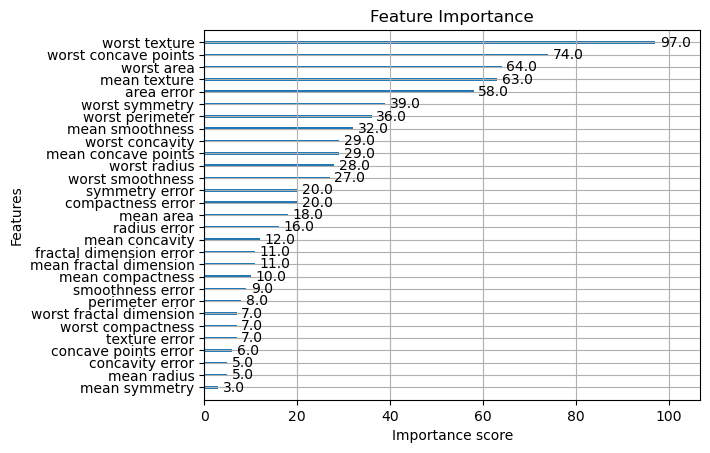

In [35]:
import matplotlib.pyplot as plt

print("Early Stopping Information: ")
print("Best Iteration:", modelr.best_iteration)
print("Best score [logloss]: ", modelr.best_score)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
xgb.plot_importance(modelr)
plt.title("Feature Importance")
plt.show()

In [3]:
# XGBoost regressor on California Housing Dataset

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

data = fetch_california_housing()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
)

regressor = XGBRegressor(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",    # regression problem
    eval_metric="rmse",
    random_state=42
)
regressor.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [4]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = regressor.predict(X_test)

print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R^2 Score:", r2_score(y_test, y_pred))

Mean Squared Error: 0.25650356056208884
R^2 Score: 0.8042568657409379
